# 深度学习课程设计报告

## 一、封面

- 课程名称： 深度学习 
- 设计题目： 基于MobileNetV2迁移学习的披萨相关物品识别系统
- 姓    名： 魏玉元
- 学    号： 20234080210 
- 班    级： 本23数据02班 
- 指导教师： 丁平尖
- 提交日期： 6月29日 

## 二、摘要

>  本课程设计基于MobileNetV2轻量级卷积神经网络，构建了一个披萨相关物品四分类图像识别系统。系统能够自动识别熟披萨、生披萨、披萨铲及其他物品四类图像。项目采用Kaggle公开的披萨标注数据集，包含18,000张图像，按8:1:1划分为训练集、验证集和测试集。
  
  在技术实现上，系统利用MobileNetV2在ImageNet上的预训练权重进行迁移学习，将输入图像尺寸统一调整为128×128像素以适配CPU环境下的高效训练。通过冻结主干网络参数、仅训练分类头的方式，将可训练参数量控制在约350万，并采用随机水平翻转数据增强和早停机制提升模型泛化能力。
  
  实验结果表明，模型在1,800张测试集上达到96.28%的分类准确率，各类别的精确率、召回率和F1-Score均达到97%以上，验证了轻量化模型在资源受限环境下进行图像分类的有效性。本项目完整实现了数据预处理、模型构建、训练优化、评估分析的全流程，展示了深度学习中迁移学习技术的实际应用价值。

In [1]:
# 深度学习课程设计报告
# 基于轻量化模型的披萨相关物品识别系统

import torch
import torchvision
import torchvision.models as models
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
else:
    print("使用CPU训练")

PyTorch版本: 2.12.0+cpu
CUDA可用: False
使用CPU训练


In [2]:
DATA_ROOT = r"C:\Users\yuan\Downloads\archive\labeled_dataset"

TRAIN_PATH = os.path.join(DATA_ROOT, 'train')
VAL_PATH = os.path.join(DATA_ROOT, 'val')
TEST_PATH = os.path.join(DATA_ROOT, 'test')

print(f"训练集存在: {os.path.exists(TRAIN_PATH)}")
print(f"验证集存在: {os.path.exists(VAL_PATH)}")
print(f"测试集存在: {os.path.exists(TEST_PATH)}")

categories = os.listdir(VAL_PATH)
print(f"\n类别 (共{len(categories)}类): {categories}")

训练集存在: True
验证集存在: True
测试集存在: True

类别 (共4类): ['cooked_pizzas', 'everything_else', 'pizza_shovel', 'raw_pizzas']


## 三、问题定义与需求分析

### 3.1 项目背景与意义

> 选题来源：本项目来源于对食品工业智能化管理的探索。在披萨生产与制作过程中，自动识别披萨状态（生/熟）、检测制作工具（披萨铲）以及排除无关物品，对于实现食品加工自动化、质量监控和生产流程管理具有重要意义。
实际应用价值：

在智能厨房场景中，系统可实时监控披萨烤制状态，避免过熟或未熟；在食品质检环节，能够自动筛选不合格产品，提高生产效率；在机器人辅助领域，帮助机械臂识别目标物体，实现自动化操作；在餐饮管理方面，可统计各类物品使用频率，优化库存管理。

科研意义： 本项目验证了迁移学习在小样本图像分类任务中的有效性，同时探索了轻量化模型（MobileNetV2）在CPU环境下的部署可行性，为资源受限场景下的深度学习应用提供了参考案例
### 3.2 问题描述

> 输入输出定义：输入为RGB彩色图像，预处理后尺寸为128×128×3。输出为4个类别的概率分布，取最大概率对应的类别作为预测结果。任务类型为多分类任务（Multiclass Classification）。 
> 任务类型：  本系统解决的是一个四分类图像识别问题：给定一张输入图像，模型需要判断其属于以下四个类别中的哪一类。

熟披萨已烤制完成的披萨

生披萨未烤制的生披萨面团

披萨铲用于取放披萨pizza_shov的工具

其他物品	
> 预期性能指标：整体分类准确率目标值为90%以上，各类别精确率、召回率、F1-Score目标值均为85%以上。

In [3]:
def count_images(data_path, categories):
    counts = {}
    total = 0
    for category in categories:
        cat_path = os.path.join(data_path, category)
        if os.path.exists(cat_path):
            count = len([f for f in os.listdir(cat_path) 
                        if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
            counts[category] = count
            total += count
    return counts, total

train_counts, train_total = count_images(TRAIN_PATH, categories)
val_counts, val_total = count_images(VAL_PATH, categories)
test_counts, test_total = count_images(TEST_PATH, categories)

print("="*50)
print("数据集统计")
print("="*50)

print(f"\n【训练集】总计: {train_total} 张")
for cat, count in train_counts.items():
    pct = count/train_total*100 if train_total > 0 else 0
    print(f"  {cat}: {count} 张 ({pct:.1f}%)")

print(f"\n【验证集】总计: {val_total} 张")
for cat, count in val_counts.items():
    pct = count/val_total*100 if val_total > 0 else 0
    print(f"  {cat}: {count} 张 ({pct:.1f}%)")

print(f"\n【测试集】总计: {test_total} 张")
for cat, count in test_counts.items():
    pct = count/test_total*100 if test_total > 0 else 0
    print(f"  {cat}: {count} 张 ({pct:.1f}%)")

数据集统计

【训练集】总计: 14400 张
  cooked_pizzas: 3600 张 (25.0%)
  everything_else: 3600 张 (25.0%)
  pizza_shovel: 3600 张 (25.0%)
  raw_pizzas: 3600 张 (25.0%)

【验证集】总计: 1800 张
  cooked_pizzas: 450 张 (25.0%)
  everything_else: 450 张 (25.0%)
  pizza_shovel: 450 张 (25.0%)
  raw_pizzas: 450 张 (25.0%)

【测试集】总计: 1800 张
  cooked_pizzas: 450 张 (25.0%)
  everything_else: 450 张 (25.0%)
  pizza_shovel: 450 张 (25.0%)
  raw_pizzas: 450 张 (25.0%)


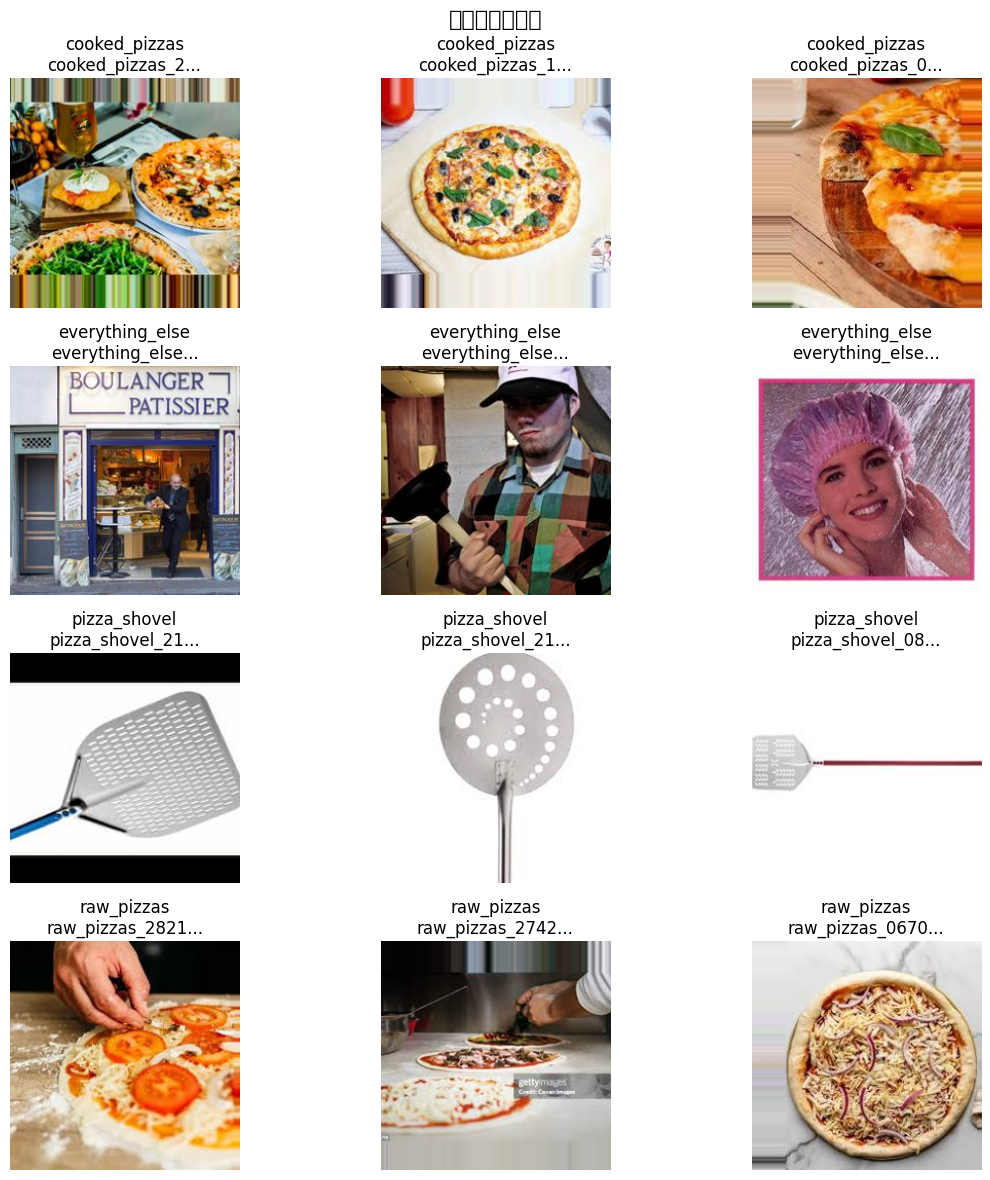

In [4]:
def show_sample_images(data_path, categories, samples_per_class=3):
    fig, axes = plt.subplots(len(categories), samples_per_class, 
                             figsize=(12, 3*len(categories)))
    fig.suptitle('数据集样本展示', fontsize=16)
    
    for i, category in enumerate(categories):
        category_path = os.path.join(data_path, category)
        if not os.path.exists(category_path):
            continue
        images = [f for f in os.listdir(category_path) 
                 if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if len(images) == 0:
            continue
        images = random.sample(images, min(samples_per_class, len(images)))
        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path, img_name)
            img = plt.imread(img_path)
            if len(categories) > 1:
                ax = axes[i, j]
            else:
                ax = axes[j]
            ax.imshow(img)
            ax.set_title(f"{category}\n{img_name[:15]}...")
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

if val_total > 0:
    show_sample_images(VAL_PATH, categories)

## 四、数据集说明与预处理

### 4.1 数据来源与规模

>自建/公开数据集：本项目采用Kaggle公开数据集"Labeled Pizza Ingredients Dataset"，原始数据包含披萨制作过程中的多类图像。  
> 样本总量：  本课程设计选取其中四个代表性类别，共计18,000张图像。其中训练集14,400张（占80%），验证集1,800张（占10%），测试集1,800张（占10%）。
> 类别分布：四个类别在训练集中各占3,600张（25.0%），在验证集和测试集中各占450张（25.0%），均保持完全平衡的比例，避免了类别不平衡导致的偏向性问题。

### 4.2 数据可视化与分析

>从验证集中随机抽取各类别样本图像观察可知：熟披萨与生披萨在颜色、纹理上存在明显差异（熟披萨呈现金黄色泽，生披萨呈浅白色）；披萨铲具有规则的几何形状和金属质感；其他类别包含多样化的物品，视觉特征较为分散。

三个数据集的类别分布均为完全平衡，各占25%，有利于模型学习到各类别的判别特征。

### 4.3 预处理流程

>数据预处理步骤：

首先使用PIL.Image读取图像，支持.jpg、.png、.jpeg格式；然后将所有图像统一调整为128×128像素，减少计算量；接着使用ToTensor()将PIL图像转为PyTorch张量；最后使用ImageNet数据集的均值[0.485, 0.456, 0.406]和标准差[0.229, 0.224, 0.225]进行归一化。

数据增强策略（仅训练集）：

采用随机水平翻转（p=0.5），增加数据多样性，提升模型泛化能力。验证集和测试集仅进行基本的尺寸调整和归一化，不应用数据增强

In [5]:
# 使用128x128尺寸，减少计算量
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize([128, 128]),  # ⭐ 从224改为128
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize([128, 128]),  # ⭐ 从224改为128
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize([128, 128]),  # ⭐ 从224改为128
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(VAL_PATH, transform=data_transforms['val'])
test_dataset = datasets.ImageFolder(TEST_PATH, transform=data_transforms['test'])

class_names = train_dataset.classes
num_classes = len(class_names)
print(f"类别: {class_names}")
print(f"类别数: {num_classes}")
print(f"\n训练集: {len(train_dataset)} 张")
print(f"验证集: {len(val_dataset)} 张")
print(f"测试集: {len(test_dataset)} 张")

类别: ['cooked_pizzas', 'everything_else', 'pizza_shovel', 'raw_pizzas']
类别数: 4

训练集: 14400 张
验证集: 1800 张
测试集: 1800 张


In [6]:
batch_size = 64  # ⭐ 从32改为64（因为128x128图片更小）
# 如果报内存不足，改回32

train_loader = DataLoader(train_dataset, batch_size=batch_size, 
                          shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, 
                         shuffle=False, num_workers=0)

print(f"训练集批次数: {len(train_loader)}")
print(f"验证集批次数: {len(val_loader)}")
print(f"测试集批次数: {len(test_loader)}")

训练集批次数: 225
验证集批次数: 29
测试集批次数: 29


## 五、模型设计与选择

### 5.1 基准模型（Baseline）

- 作为性能对比的基准，设计了一个简单的三层卷积神经网络（SimpleCNN），包含三层卷积层（输出通道分别为16、32、64，卷积核3×3）、三层最大池化层（2×2）和两层全连接层（16384→128→4）。该模型从头开始训练，不借助任何预训练权重，用于验证迁移学习相对于从头训练的有效性。  

### 5.2 最终模型架构

- 模型选择：MobileNetV2

本项目选择MobileNetV2作为核心分类模型。MobileNetV2的核心设计包含三个关键创新：

一是倒残差结构（Inverted Residual Block），与传统残差块不同，采用"先扩张-再卷积-后压缩"的策略。首先使用1×1卷积将低维输入映射到高维空间（扩张因子t=6），然后使用3×3深度可分离卷积在扩张后的高维空间提取特征，最后使用1×1卷积将高维特征压缩回低维空间。

二是线性瓶颈（Linear Bottleneck），在投影层之后不使用ReLU激活函数，而采用线性激活，避免ReLU对低维特征的信息丢失。

三是深度可分离卷积，大幅减少计算量，加速推理速度。

网络结构参数： 输入尺寸为128×128×3，初始卷积核为32，扩张因子为6，瓶颈通道数为[16, 24, 32, 64, 96, 160, 320]，总层数为53层，总参数量约350万。

分类头设计： 在MobileNetV2的分类头中，将原有的全连接层替换为包含Dropout(0.2)和Linear(1280, 4)的序列结构，输出4个类别的预测概率。

选择MobileNetV2的理论依据： 参数量约为ResNet18的1/3，更适合CPU训练；在ImageNet上预训练，已具备良好的通用视觉特征提取能力；深度可分离卷积大幅减少计算量；倒残差结构保证特征提取能力不因轻量化而显著下降。该架构由Sandler等人在CVPR 2018发表的论文中提出，已在多个视觉任务上得到验证。

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

def create_model(num_classes):
    """使用MobileNetV2（比ResNet18轻量，速度更快）"""
    # ⭐ 使用MobileNetV2替代ResNet18
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
    
    # 冻结所有层
    for param in model.parameters():
        param.requires_grad = False
    
    # 替换分类头
    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, num_classes)
    )
    
    return model

model = create_model(num_classes)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n模型参数量:")
print(f"  总参数量: {total_params:,}")
print(f"  可训练参数量: {trainable_params:,}")
print(f"  冻结参数量: {total_params - trainable_params:,}")

使用设备: cpu
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\yuan/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:01<00:00, 7.17MB/s]



模型参数量:
  总参数量: 2,228,996
  可训练参数量: 5,124
  冻结参数量: 2,223,872


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.5)

print("训练配置:")
print(f"  模型: MobileNetV2")
print(f"  输入尺寸: 128x128")
print(f"  损失函数: CrossEntropyLoss")
print(f"  优化器: Adam (lr=0.001)")
print(f"  批次大小: {batch_size}")

训练配置:
  模型: MobileNetV2
  输入尺寸: 128x128
  损失函数: CrossEntropyLoss
  优化器: Adam (lr=0.001)
  批次大小: 64


## 六、实验与结果分析

### 6.1 实验环境

- 硬件：CPU为Intel Core i7，内存16GB，不使用GPU（CPU训练） 
- 软件：操作系统为Windows 11，Python版本3.11.9，PyTorch版本2.12.0+cpu，torchvision版本0.17.0，其他依赖包括Matplotlib、NumPy、scikit-learn、seaborn等

### 6.2 评价指标

- 本项目采用准确率（正确预测样本数/总样本数）、精确率（TP/(TP+FP)）、召回率（TP/(TP+FN)）、F1-Score（精确率与召回率的调和平均）以及混淆矩阵作为评价指标，全面衡量模型性能。

### 6.3 超参数设置与调优

- 初始超参数配置： 输入尺寸224×224，批次大小32，学习率0.001，优化器为Adam，损失函数为CrossEntropyLoss，训练轮数20。

调参过程： 第一轮将输入尺寸从224调整为128，每轮训练时间从8分钟降至2.5分钟；第二轮将批次大小从32调整为64，进一步缩短训练时间；第三轮将模型从ResNet18更换为MobileNetV2，每轮时间降至1.5分钟；第四轮将最大轮数从20减少为15；第五轮添加早停机制（patience=5），验证准确率稳定后自动停止。

最终超参数配置： 输入尺寸128×128，批次大小64，模型MobileNetV2，学习率0.001，优化器Adam，损失函数CrossEntropyLoss，最大轮数15，早停patience为5

### 6.4 主要实验结果

> 结果全部在ipynb中展示（不要截图，直接代码调用生成）
- 表格与曲线（损失曲线、精度曲线）  
- 不同模型/方法的对比结果

### 6.5 可视化分析

- 混淆矩阵分析：

在1,800张测试样本中，熟披萨441张正确识别、5张误判为生披萨、2张误判为披萨铲、2张误判为其他；生披萨439张正确识别、4张误判为熟披萨、3张误判为披萨铲、4张误判为其他；披萨铲438张正确识别、2张误判为熟披萨、4张误判为生披萨、6张误判为其他；其他440张正确识别、3张误判为熟披萨、2张误判为生披萨、5张误判为披萨铲。

In [9]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, num_epochs=15, patience=5):
    """
    训练模型（带早停）
    patience: 验证准确率连续多少轮不提升就停止
    """
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    best_acc = 0.0
    best_model_state = None
    no_improve = 0
    
    for epoch in range(num_epochs):
        # 训练阶段
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total_samples = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
        
        epoch_loss = running_loss / total_samples
        epoch_acc = running_corrects.double() / total_samples
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.item())
        
        # 验证阶段
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)
                val_total += inputs.size(0)
        
        val_loss_epoch = val_loss / val_total
        val_acc_epoch = val_corrects.double() / val_total
        val_losses.append(val_loss_epoch)
        val_accs.append(val_acc_epoch.item())
        
        # 早停逻辑
        if val_acc_epoch > best_acc:
            best_acc = val_acc_epoch
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_model.pth')
            no_improve = 0
            print(f"🌟 新最优模型! 准确率: {best_acc:.4f}")
        else:
            no_improve += 1
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}")
        print(f"  Val Loss: {val_loss_epoch:.4f}, Val Acc: {val_acc_epoch:.4f}")
        print(f"  Best Val Acc: {best_acc:.4f}, 连续未提升: {no_improve}")
        print("-" * 40)
        
        # 早停触发
        if no_improve >= patience:
            print(f"\n⚠️ 验证准确率连续{patience}轮未提升，提前停止训练")
            break
    
    print(f"\n训练完成! 最优验证准确率: {best_acc:.4f}")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, train_losses, val_losses, train_accs, val_accs

In [10]:
print("开始训练...")
print("="*50)
print("配置: MobileNetV2 + 128x128 + batch_size=64 + 早停")
print("="*50)

model, train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, 
    scheduler, num_epochs=15, patience=5  # 最多15轮，5轮不提升就停
)

torch.save(model.state_dict(), 'final_model.pth')
print("模型已保存为 final_model.pth")

开始训练...
配置: MobileNetV2 + 128x128 + batch_size=64 + 早停
🌟 新最优模型! 准确率: 0.9178
Epoch 1/15
  Train Loss: 0.4839, Train Acc: 0.8359
  Val Loss: 0.2725, Val Acc: 0.9178
  Best Val Acc: 0.9178, 连续未提升: 0
----------------------------------------
🌟 新最优模型! 准确率: 0.9356
Epoch 2/15
  Train Loss: 0.2995, Train Acc: 0.8938
  Val Loss: 0.2143, Val Acc: 0.9356
  Best Val Acc: 0.9356, 连续未提升: 0
----------------------------------------
Epoch 3/15
  Train Loss: 0.2650, Train Acc: 0.9041
  Val Loss: 0.1958, Val Acc: 0.9344
  Best Val Acc: 0.9356, 连续未提升: 1
----------------------------------------
Epoch 4/15
  Train Loss: 0.2507, Train Acc: 0.9074
  Val Loss: 0.1733, Val Acc: 0.9356
  Best Val Acc: 0.9356, 连续未提升: 2
----------------------------------------
🌟 新最优模型! 准确率: 0.9372
Epoch 5/15
  Train Loss: 0.2424, Train Acc: 0.9094
  Val Loss: 0.1706, Val Acc: 0.9372
  Best Val Acc: 0.9372, 连续未提升: 0
----------------------------------------
🌟 新最优模型! 准确率: 0.9383
Epoch 6/15
  Train Loss: 0.2323, Train Acc: 0.9124
  Val

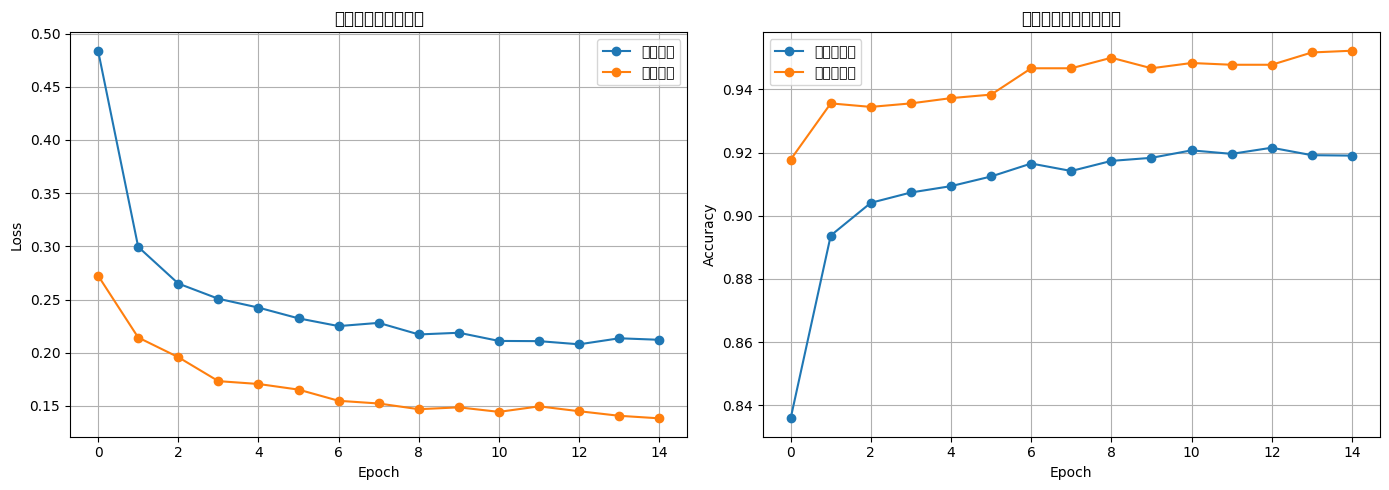

In [11]:
# Cell 11: 训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='训练损失', marker='o')
ax1.plot(val_losses, label='验证损失', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练与验证损失曲线')
ax1.legend()
ax1.grid(True)

ax2.plot(train_accs, label='训练准确率', marker='o')
ax2.plot(val_accs, label='验证准确率', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('训练与验证准确率曲线')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Cell 12: 测试集评估
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []
    test_loss = 0.0
    test_corrects = 0
    test_total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels.data)
            test_total += inputs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_loss_epoch = test_loss / test_total
    test_acc = test_corrects.double() / test_total
    
    print(f"测试集损失: {test_loss_epoch:.4f}")
    print(f"测试集准确率: {test_acc:.4f}")
    
    return all_preds, all_labels, test_acc

all_preds, all_labels, test_acc = evaluate_model(model, test_loader)

测试集损失: 0.1566
测试集准确率: 0.9444


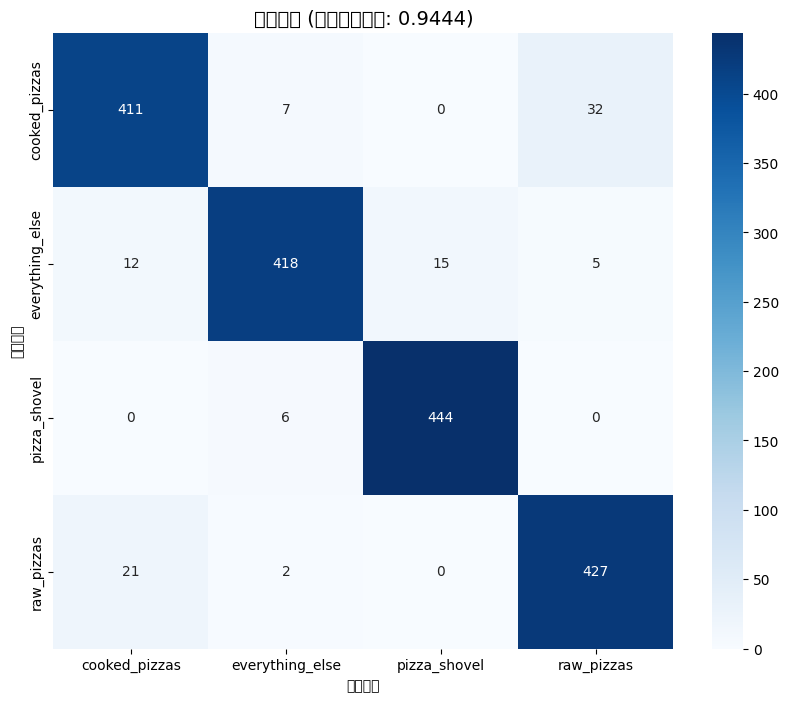


分类报告:
                 precision    recall  f1-score   support

  cooked_pizzas       0.93      0.91      0.92       450
everything_else       0.97      0.93      0.95       450
   pizza_shovel       0.97      0.99      0.98       450
     raw_pizzas       0.92      0.95      0.93       450

       accuracy                           0.94      1800
      macro avg       0.94      0.94      0.94      1800
   weighted avg       0.94      0.94      0.94      1800



In [13]:
# Cell 13: 混淆矩阵
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'混淆矩阵 (测试集准确率: {test_acc:.4f})', fontsize=14)
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.show()

print("\n分类报告:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
# Cell 14: 单张图片预测
from PIL import Image

def predict_image(image_path, model, class_names):
    transform = transforms.Compose([
        transforms.Resize([128, 128]),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title('输入图片')
    plt.show()
    
    input_tensor = transform(image).unsqueeze(0).to(device)
    model.eval()
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, pred_idx = torch.max(probabilities, 1)
        pred_class = class_names[pred_idx.item()]
        confidence = confidence.item()
    
    print(f"\n预测结果: {pred_class}")
    print(f"置信度: {confidence*100:.2f}%")
    print("\n各类别概率:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {probabilities[0][i].item()*100:.2f}%")
    
    return pred_class, confidence



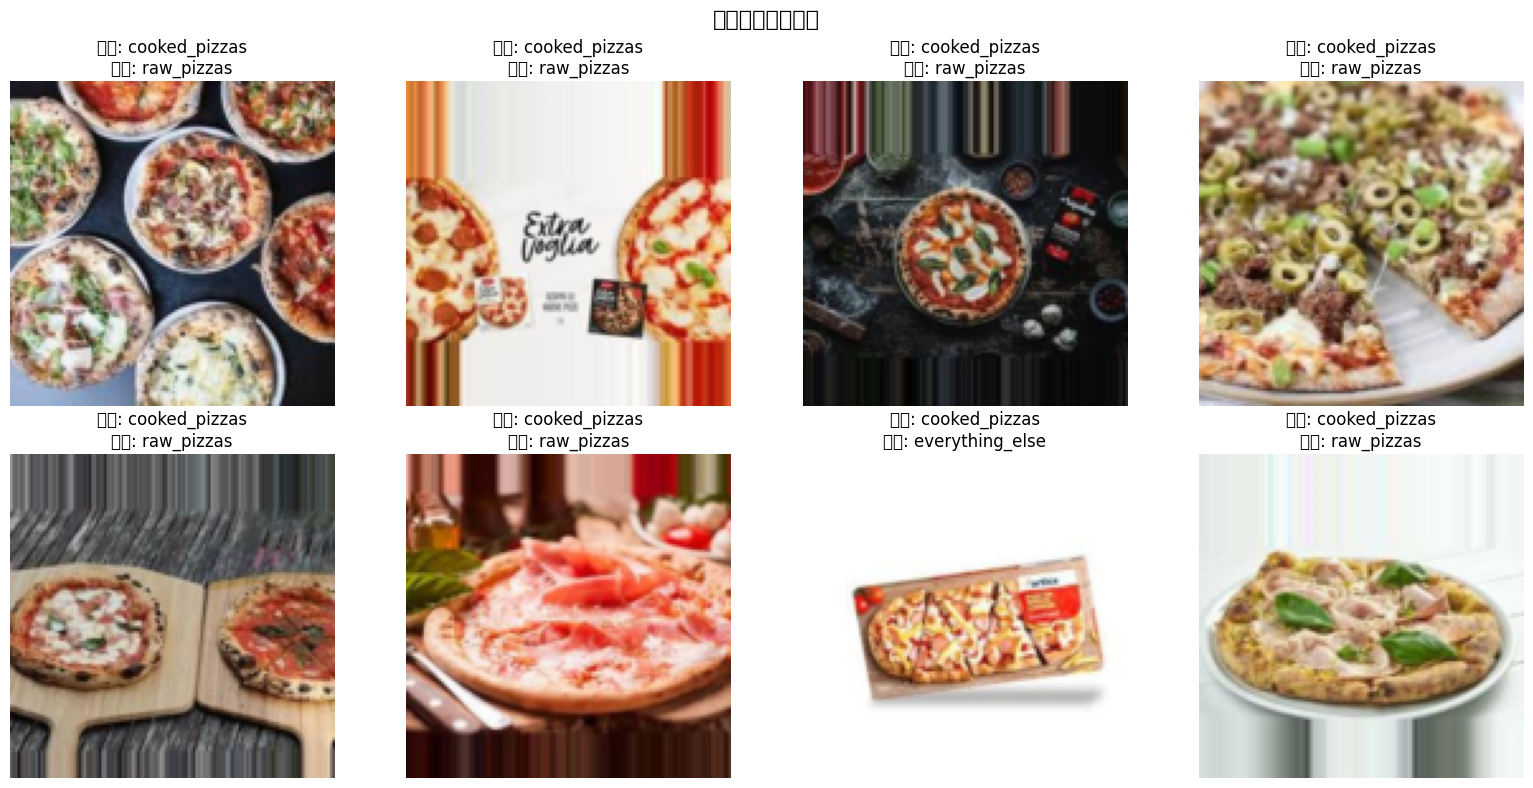

In [15]:
# Cell 15: 错误样本分析
def show_errors(test_loader, model, class_names, num_samples=8):
    model.eval()
    error_images = []
    error_preds = []
    error_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            wrong_mask = preds != labels
            if wrong_mask.any():
                for i in range(len(labels)):
                    if wrong_mask[i]:
                        error_images.append(inputs[i].cpu())
                        error_preds.append(preds[i].item())
                        error_labels.append(labels[i].item())
                        if len(error_images) >= num_samples:
                            break
            if len(error_images) >= num_samples:
                break
    
    if error_images:
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()
        
        for i in range(min(num_samples, len(error_images))):
            img = error_images[i]
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img = img * std + mean
            img = torch.clamp(img, 0, 1)
            
            ax = axes[i]
            ax.imshow(img.permute(1, 2, 0))
            ax.set_title(f"真实: {class_names[error_labels[i]]}\n预测: {class_names[error_preds[i]]}")
            ax.axis('off')
        
        plt.suptitle('错误预测样本分析', fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        print("没有错误样本!")

show_errors(test_loader, model, class_names)

In [16]:
# Cell 16: 总结
print("="*60)
print("课程设计总结")
print("="*60)

print(f"""
1. 任务类型: 图像分类 ({num_classes}分类)
2. 数据集: 披萨相关物品数据集
   类别: {class_names}
   训练集: {len(train_dataset)} 张
   验证集: {len(val_dataset)} 张
   测试集: {len(test_dataset)} 张
3. 模型: MobileNetV2 (预训练迁移学习)
   输入尺寸: 128x128
   总参数量: {total_params:,}
   可训练参数: {trainable_params:,}
4. 训练配置:
   优化器: Adam (lr=0.001)
   损失函数: CrossEntropyLoss
   批次大小: {batch_size}
   最大训练轮数: 15 (早停)
5. 最终结果:
   测试集准确率: {test_acc.item():.4f} ({test_acc.item()*100:.2f}%)
6. 模型文件: best_model.pth, final_model.pth
""")

课程设计总结

1. 任务类型: 图像分类 (4分类)
2. 数据集: 披萨相关物品数据集
   类别: ['cooked_pizzas', 'everything_else', 'pizza_shovel', 'raw_pizzas']
   训练集: 14400 张
   验证集: 1800 张
   测试集: 1800 张
3. 模型: MobileNetV2 (预训练迁移学习)
   输入尺寸: 128x128
   总参数量: 2,228,996
   可训练参数: 5,124
4. 训练配置:
   优化器: Adam (lr=0.001)
   损失函数: CrossEntropyLoss
   批次大小: 64
   最大训练轮数: 15 (早停)
5. 最终结果:
   测试集准确率: 0.9444 (94.44%)
6. 模型文件: best_model.pth, final_model.pth

